## Introduction 

In this script, the global closeness per ward is computed but only for the drivable roads.  

## Reading in the Python libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [5]:
BASE_DIR = Path.cwd().parents[1]
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_chennai" / "chennai_graphml_drive.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [6]:
## Detailed wards
df_inpath = PROCESSED_DIR / "chennai_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\chennai_fix_mapshaper.shp


In [7]:
df = gpd.read_file(df_inpath)
df.head()

,Name,zone_id,zone_name,geometry
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584..."
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ..."
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ..."
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13...."
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318..."


In [8]:
print(f'There are {df.shape[0]} wards in the dataset.')

There are 200 wards in the dataset.


Reading in the entire Bangalore network data that we had downloaded earlier as again we will "truncate" the network to the different street networks at the ward level:

In [9]:
G = ox.io.load_graphml(path_graphml)

In [10]:
G.graph["crs"]

'epsg:4326'

In [11]:
df.crs.to_epsg()

4326

## Computing (global) closeness at the ward level

In [15]:
results = pd.DataFrame(columns=['Name', 'zone_id', 'zone_name', 'closeness'])
results

,Name,zone_id,zone_name,closeness


In [16]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    ## print(f'Processing the {ward} ward.')

    Name = df['Name'].iloc[ward]
    zone_id = df['zone_id'].iloc[ward]
    zone_name = df['zone_name'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]

    ## https://docs.momepy.org/en/stable/user_guide/simple/shape.html#Street-network-shapes
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    streets_graph = ox.projection.project_graph(G_clipped)

    edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

    primal = momepy.gdf_to_nx(edges, approach="primal")

    primal = momepy.closeness_centrality(primal, name='closeness_global', weight='mm_len')

    nodes = momepy.nx_to_gdf(primal, lines=False)

    closeness_mean = nodes['closeness_global'].mean()

    results.loc[ward] = [
        Name,
        zone_id,
        zone_name,
        closeness_mean
    ]
    

Processing wards: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [11:59<00:00,  3.60s/it]


In [17]:
results

,Name,zone_id,zone_name,closeness
0,168,13,Adyar,0.000745
1,169,13,Adyar,0.000576
2,170,13,Adyar,0.000717
3,171,13,Adyar,0.000804
4,174,13,Adyar,0.000934
...,...,...,...,...
195,110,9,Teynampet,0.000792
196,161,12,Alandur,0.000800
197,160,12,Alandur,0.001745
198,195,15,Sholinganallur,0.000737


In [18]:
top10_highest = (
    results
    .sort_values(by='closeness', ascending=False)
    .head(10)
)
top10_highest

,Name,zone_id,zone_name,closeness
129,51,5,Royapuram,0.002099
95,77,6,Thiru-Vi-Ka. Nagar,0.002054
166,13,1,Thiruvottyur,0.001999
103,72,6,Thiru-Vi-Ka. Nagar,0.001942
119,54,5,Royapuram,0.001924
167,14,1,Thiruvottyur,0.001914
120,55,5,Royapuram,0.001898
148,48,4,Tondiarpet,0.001869
121,56,5,Royapuram,0.001868
163,8,1,Thiruvottyur,0.001856


In [19]:
top10_lowest = (
    results
    .sort_values(by='closeness', ascending=True)
    .head(10)
)
top10_lowest

,Name,zone_id,zone_name,closeness
17,200,15,Sholinganallur,0.000349
71,83,7,Ambattur,0.000417
107,150,11,Valasaravakkam,0.000439
62,17,2,Manali,0.000462
19,197,15,Sholinganallur,0.000486
74,86,7,Ambattur,0.000488
177,32,3,Madhavaram,0.000513
15,199,15,Sholinganallur,0.000540
61,16,2,Manali,0.000547
27,191,14,Perungudi,0.000554


In [20]:
print(f'The mean of the global closeness across the wards is {results["closeness"].mean()}.')
print(f'The minimum of the global closeness across the wards is {results["closeness"].min()}.')
print(f'The maximum of the global closeness across the wards is {results["closeness"].max()}.')

The mean of the global closeness across the wards is 0.0010467954973386643.
The minimum of the global closeness across the wards is 0.0003493480060704371.
The maximum of the global closeness across the wards is 0.002098904852604913.


In [21]:
## Save this:
results_path = PROCESSED_DIR / "results_chennai_global_closeness_all_roads_drive.csv"

results.to_csv(results_path)

In [22]:
# You can normally do things from results but I had to read them in later
results_path = PROCESSED_DIR / "results_chennai_global_closeness_all_roads_drive.csv"
results = pd.read_csv(results_path)

In [23]:
results = pd.read_csv(results_path)
results

,Unnamed: 0,Name,zone_id,zone_name,closeness
0,0,168,13,Adyar,0.000745
1,1,169,13,Adyar,0.000576
2,2,170,13,Adyar,0.000717
3,3,171,13,Adyar,0.000804
4,4,174,13,Adyar,0.000934
...,...,...,...,...,...
195,195,110,9,Teynampet,0.000792
196,196,161,12,Alandur,0.000800
197,197,160,12,Alandur,0.001745
198,198,195,15,Sholinganallur,0.000737


In [24]:
df_merged = df.merge(results, on = 'Name')
df_merged

,Name,zone_id_x,zone_name_x,geometry,Unnamed: 0,zone_id_y,zone_name_y,closeness
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",0,13,Adyar,0.000745
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",1,13,Adyar,0.000576
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",2,13,Adyar,0.000717
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",3,13,Adyar,0.000804
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",4,13,Adyar,0.000934
...,...,...,...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",195,9,Teynampet,0.000792
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",196,12,Alandur,0.000800
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",197,12,Alandur,0.001745
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",198,15,Sholinganallur,0.000737


In [25]:
df_merged = df_merged[['Name', 'zone_id_x', 'zone_name_x', 'geometry', 'closeness']]
df_merged

,Name,zone_id_x,zone_name_x,geometry,closeness
0,168,13,Adyar,"POLYGON ((80.20975 13.02585, 80.20975 13.02584...",0.000745
1,169,13,Adyar,"POLYGON ((80.22123 13.0123, 80.22123 13.0123, ...",0.000576
2,170,13,Adyar,"POLYGON ((80.24038 13.0067, 80.2404 13.00679, ...",0.000717
3,171,13,Adyar,"MULTIPOLYGON (((80.27408 13.0133, 80.27284 13....",0.000804
4,174,13,Adyar,"POLYGON ((80.25905 13.01289, 80.26012 13.01318...",0.000934
...,...,...,...,...,...
195,110,9,Teynampet,"POLYGON ((80.23114 13.05407, 80.23115 13.05415...",0.000792
196,161,12,Alandur,"POLYGON ((80.20783 13.00072, 80.20781 13.00064...",0.000800
197,160,12,Alandur,"MULTIPOLYGON (((80.20702 12.99931, 80.20702 12...",0.001745
198,195,15,Sholinganallur,"POLYGON ((80.24569 12.93725, 80.24554 12.93576...",0.000737


In [26]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'zone_id_x': 'zone_id',
    'zone_name_x': 'zone_name'
})

## Plots

The ward with the highest straightness

In [27]:
# Find the index label of the row with the maximum value in column 'C'
mask = df_merged['closeness'] == df_merged['closeness'].max()

# Apply the mask to the DataFrame
max_rows_df = df_merged[mask]

print(max_rows_df)

     Name  zone_id  zone_name  \
129    51        5  Royapuram   

                                              geometry  closeness  
129  POLYGON ((80.2863 13.11639, 80.28631 13.1164, ...   0.002099  


In [28]:
print(f'The ward with the highest closeness is {max_rows_df["Name"]}')


The ward with the highest closeness is 129    51
Name: Name, dtype: int32


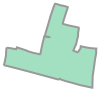

In [29]:
geom_highest = max_rows_df.geometry.iloc[0]
geom_highest

In [30]:
# Find the index label of the row with the maximum value in column 'C'
mask = df_merged['closeness'] == df_merged['closeness'].min()

# Apply the mask to the DataFrame
min_rows_df = df_merged[mask]

print(min_rows_df)

    Name  zone_id       zone_name  \
17   200       15  Sholinganallur   

                                             geometry  closeness  
17  POLYGON ((80.21061 12.87956, 80.21062 12.87956...   0.000349  


In [31]:
print(f'The ward with the lowest straightness is {min_rows_df["Name"]}')

The ward with the lowest straightness is 17    200
Name: Name, dtype: int32


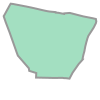

In [32]:
geom_lowest = min_rows_df.geometry.iloc[0]
geom_lowest

In [33]:
G_clipped_lowest = ox.truncate.truncate_graph_polygon(G, geom_lowest)

In [34]:
# path_gpkg_bang_truncated = PROCESSED_DIR / "gpkg_chennai" / "test_truncated.gpkg"
# ox.io.save_graph_geopackage(G_clipped_lowest, filepath=path_gpkg_bang_truncated)

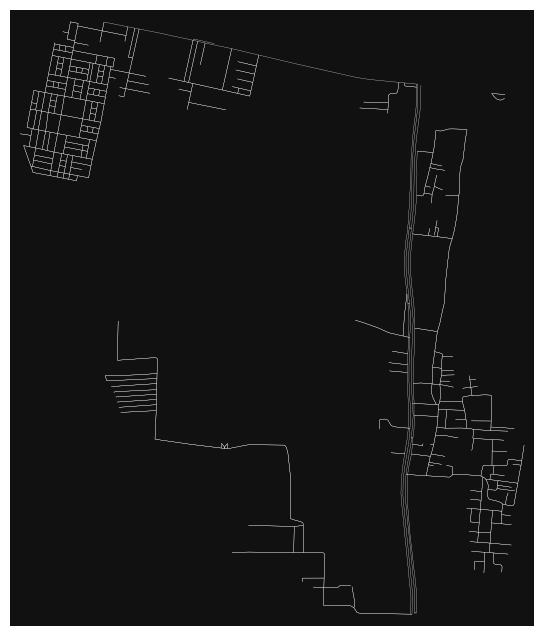

In [35]:
fig, ax = ox.plot_graph(G_clipped_lowest, node_size=0, edge_color="w", edge_linewidth=0.2)

Plot the closeness at the wards:

In [36]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'closeness_global_all_roads_chennai_drive.png'

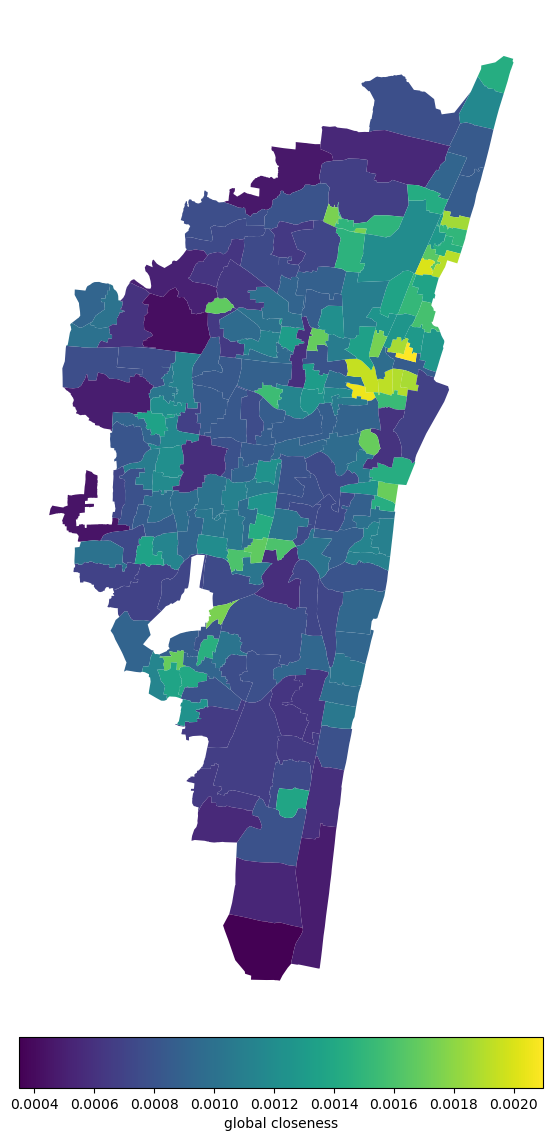

In [37]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="closeness",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "global closeness", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()